# Decision Trees: Heart Disease Prediction

## Problem Statement
A hospital wants to identify patients at risk of heart disease using clinical data.
We will use decision trees to classify patients as positive or negative for heart disease,
and then apply regression trees to estimate the time to an expected heart incident (ytr).

## Dataset
303 patient records with the following features:
- `age` : Age of the patient (in years)
- `sex` :Gender of the patient (0 = female, 1 = male)
- `BP` :Blood pressure measurement (mmHg)
- `cholestrol` : Serum cholesterol level (mg/dL)
- `heart disease` :Target variable, presence (1) or absence (0) of heart disease
- `ytr` : Estimated time to an expected heart incident (in years)

## Pipeline
1. Data Loading and Exploration
2. Classification Tree, predict presence of heart disease
3. Regression Tree, predict time to heart incident (ytr)
4. Hyperparameter Tuning, GridSearchCV for optimal depth and splits
5. Feature Importance Analysis

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, precision_score,
                             recall_score, mean_squared_error)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [4]:
## 1. Load the Data
df = pd.read_csv('heart_disease_data.csv')

print(f'Shape: {df.shape}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nHeart disease rate: {df["heart disease"].mean():.1%}')
df.head()

Shape: (303, 6)

Data types:
age                int64
sex                int64
BP                 int64
cholestrol         int64
heart disease      int64
ytr              float64
dtype: object

Missing values: 0

Heart disease rate: 19.1%


,age,sex,BP,cholestrol,heart disease,ytr
0,67,1,129,233,0,6.9
1,57,1,125,287,1,3.7
2,43,0,135,197,0,6.3
3,71,1,111,257,0,5.0
4,36,1,136,258,0,6.1


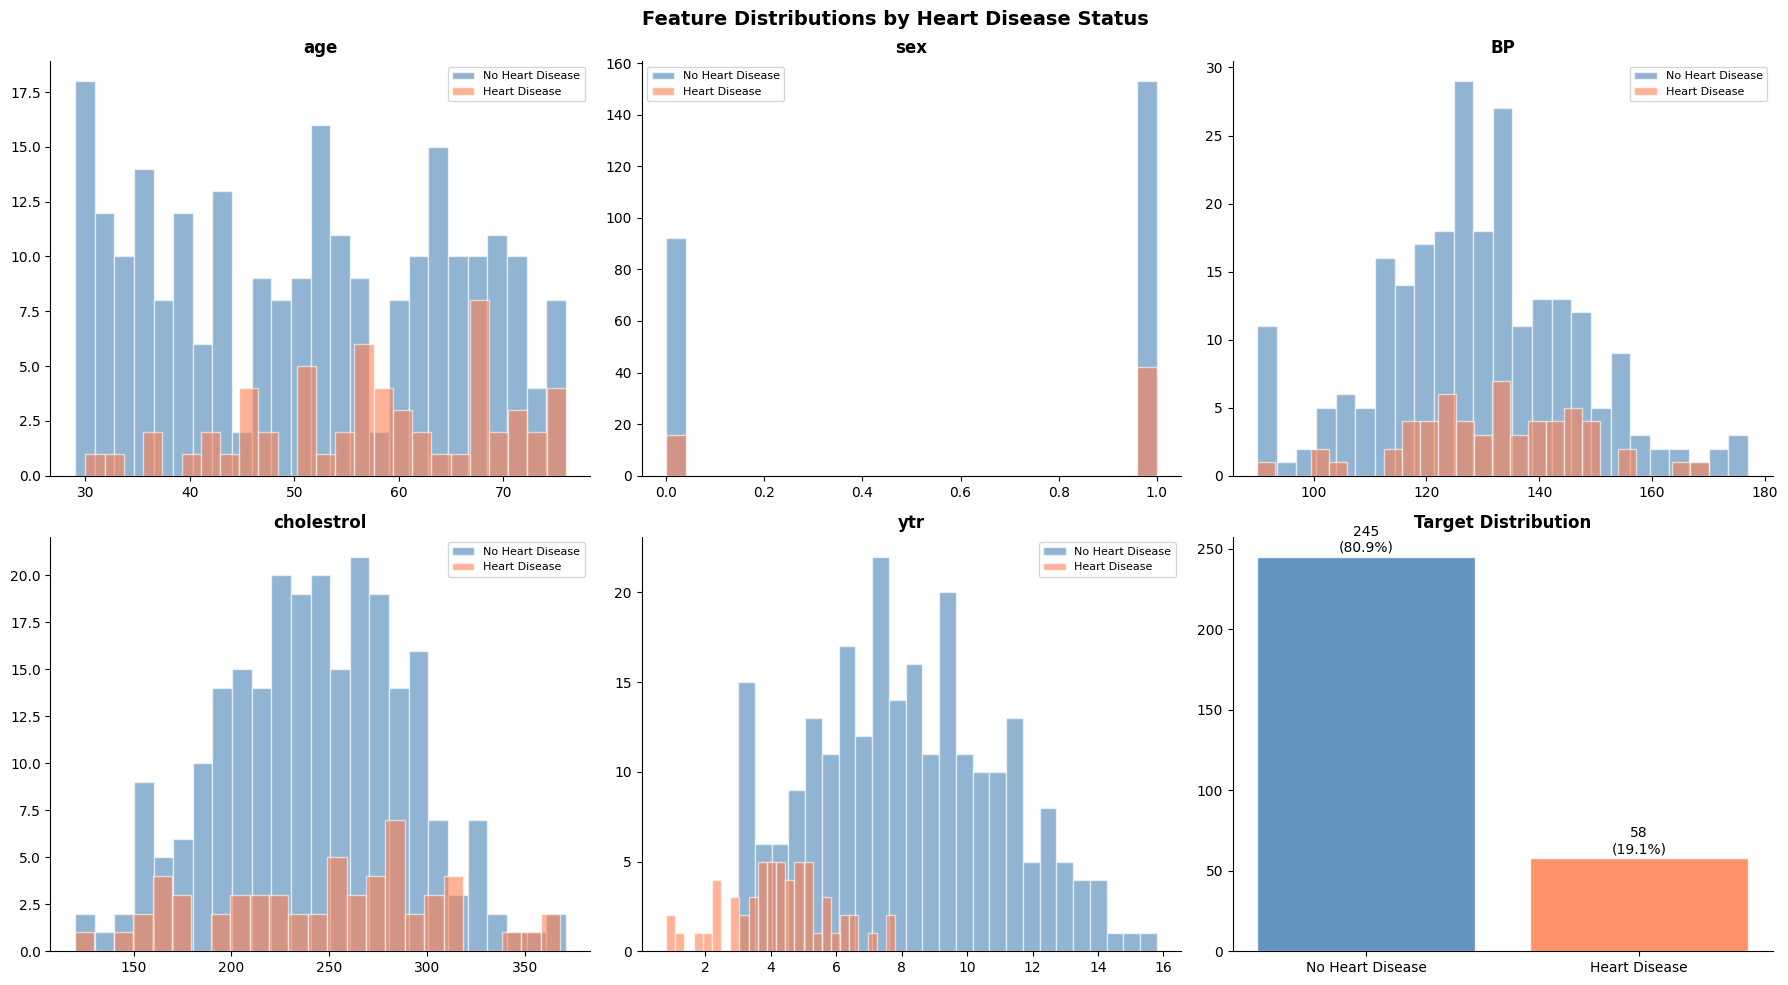

In [5]:
## 2. EDA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['age', 'sex', 'BP', 'cholestrol', 'ytr']

# Distribution of each feature by heart disease status
for i, col in enumerate(features):
    axes[i].hist(df[df['heart disease']==0][col], bins=25, alpha=0.6,
                 color='steelblue', label='No Heart Disease', edgecolor='white')
    axes[i].hist(df[df['heart disease']==1][col], bins=25, alpha=0.6,
                 color='coral', label='Heart Disease', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

# Target distribution
labels = ['No Heart Disease', 'Heart Disease']
counts = df['heart disease'].value_counts().sort_index()
axes[5].bar(labels, counts.values, color=['steelblue', 'coral'], alpha=0.85, edgecolor='white')
axes[5].set_title('Target Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[5].text(i, v + 3, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=10)

plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
## 3. Classification Tree

# 3.1 Train/test split
X = df[['age', 'sex', 'BP', 'cholestrol']]
y = df['heart disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Train disease rate: {y_train.mean():.1%}')
print(f'Test  disease rate: {y_test.mean():.1%}')


X_train: (242, 4), X_test: (61, 4)
Train disease rate: 19.0%
Test  disease rate: 19.7%


In [7]:
# 3.2 Train default tree (no depth limit let it grow fully)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f'\nDefault Tree (unpruned)')
print(f'  Depth     : {clf.get_depth()}')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'  F1        : {f1_score(y_test, y_pred):.4f}')


Default Tree (unpruned)
  Depth     : 15
  Accuracy  : 0.6557
  Precision : 0.1538
  Recall    : 0.1667
  F1        : 0.1600


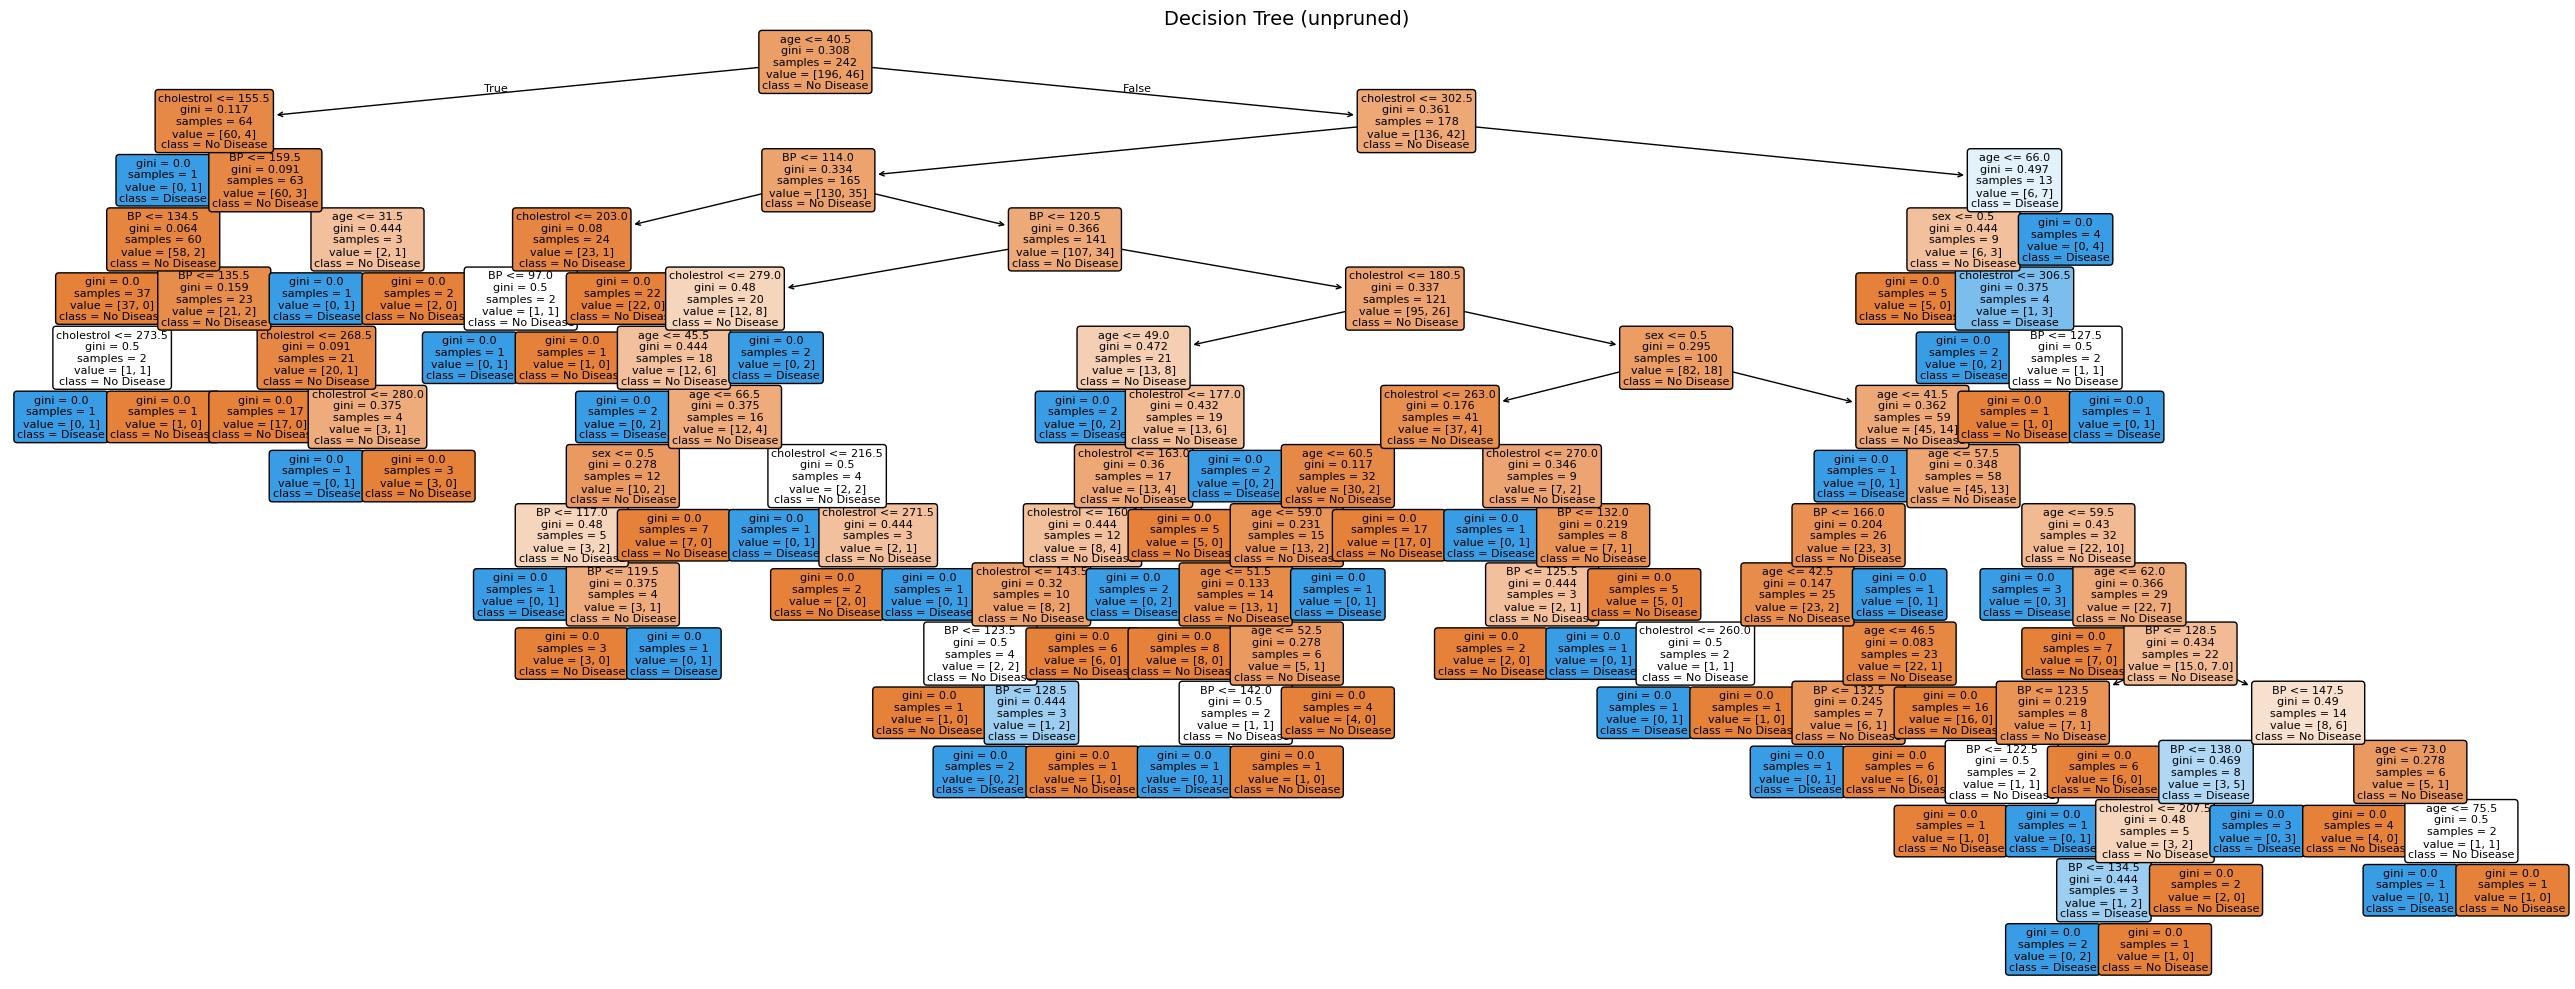

In [10]:
# Visualise the unpruned tree
plt.figure(figsize=(26, 10))
plot_tree(
    clf,
    feature_names=['age', 'sex', 'BP', 'cholestrol'],
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=8,

)
plt.title('Decision Tree (unpruned)', fontsize=14)
plt.tight_layout()
plt.show()

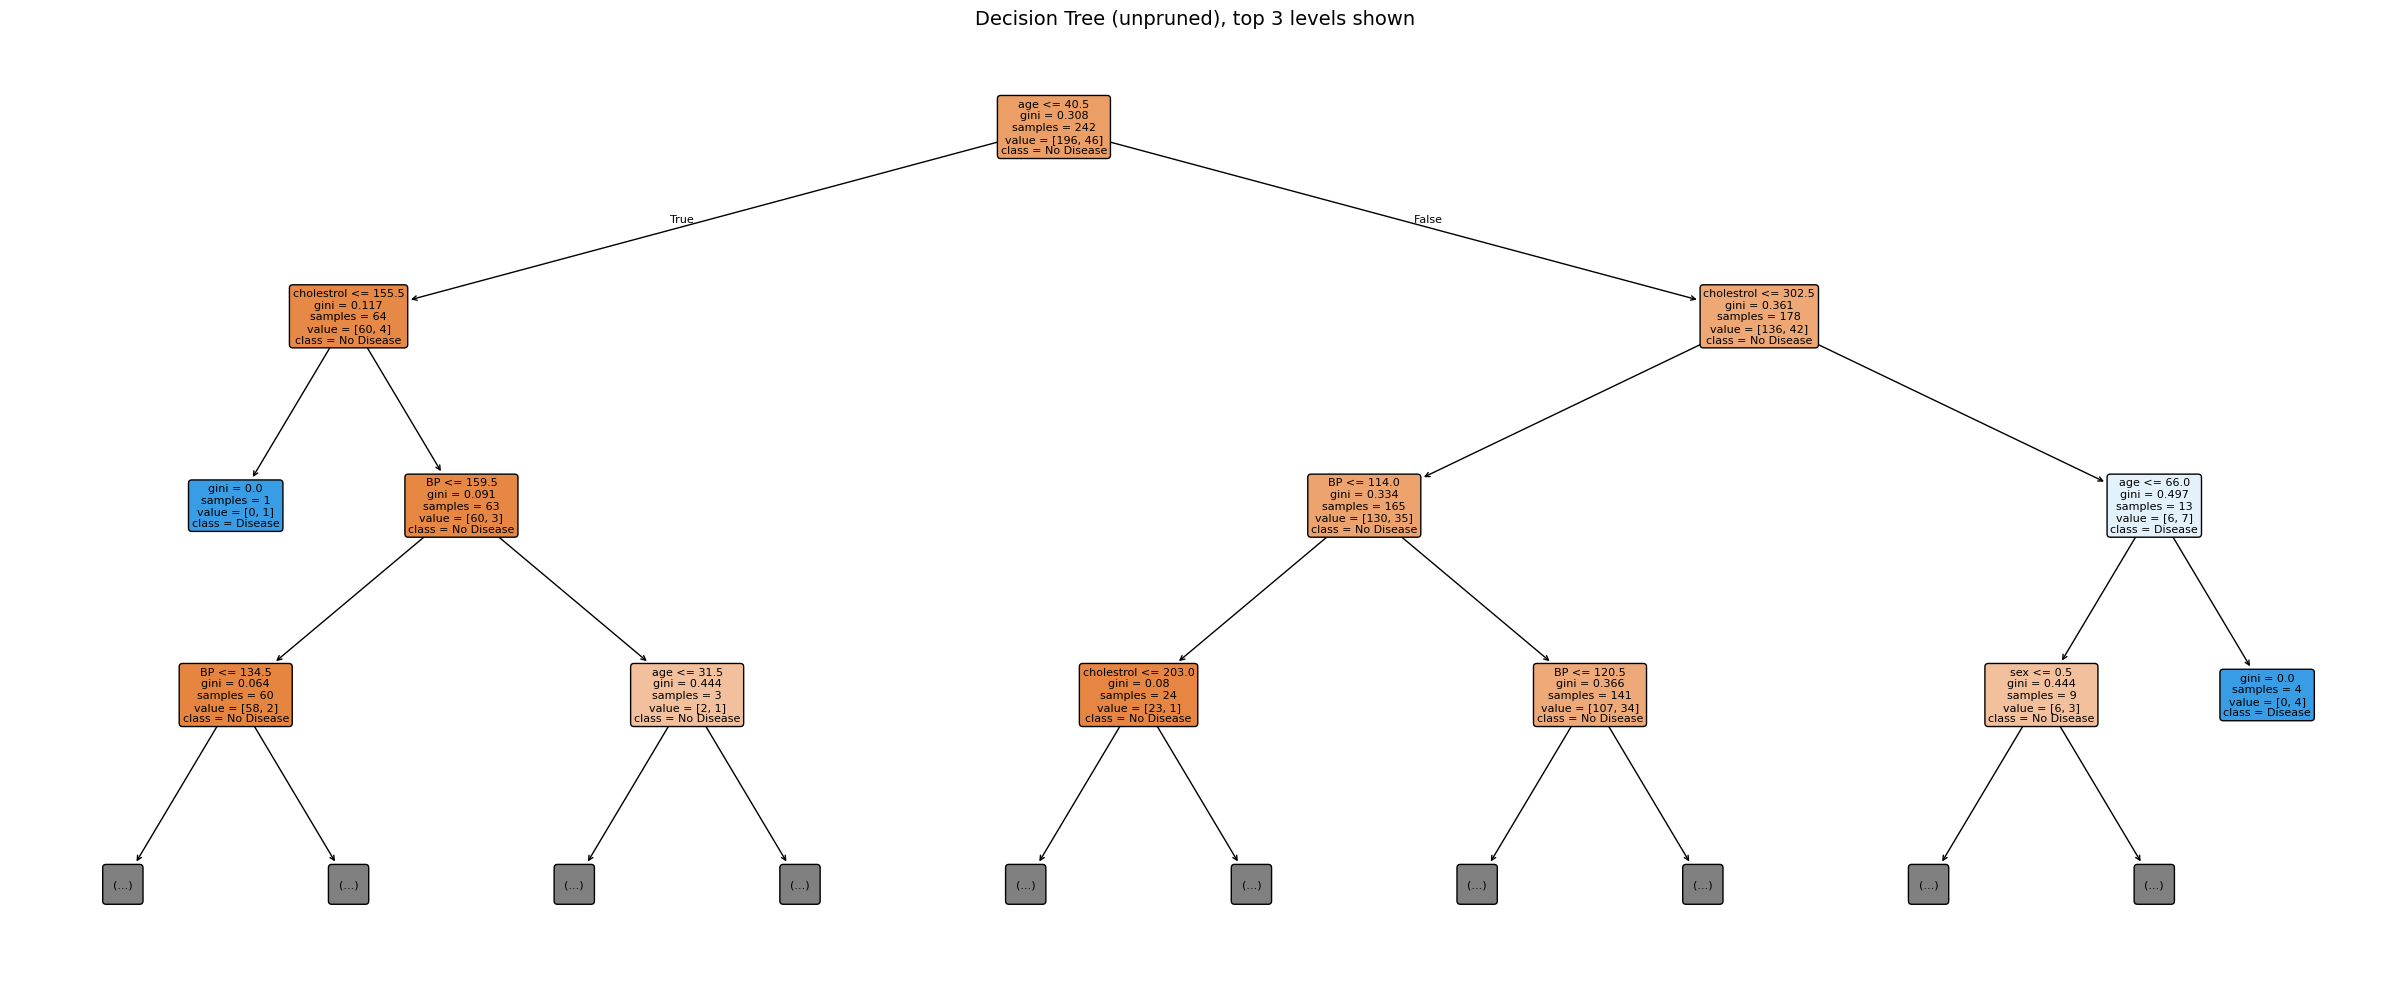

In [11]:
# Visualise the unpruned tree, show top 3 levels only as full tree is unreadable
plt.figure(figsize=(24, 10))
plot_tree(
    clf,
    feature_names=['age', 'sex', 'BP', 'cholestrol'],
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title('Decision Tree (unpruned), top 3 levels shown', fontsize=14)
plt.tight_layout()
plt.show()

 depth  accuracy       f1   recall
     1  0.803279 0.000000 0.000000
     2  0.770492 0.300000 0.250000
     3  0.803279 0.142857 0.083333
     4  0.770492 0.125000 0.083333
     5  0.737705 0.111111 0.083333
     6  0.721311 0.105263 0.083333
     7  0.704918 0.100000 0.083333
     8  0.704918 0.100000 0.083333
     9  0.672131 0.090909 0.083333
    10  0.672131 0.090909 0.083333


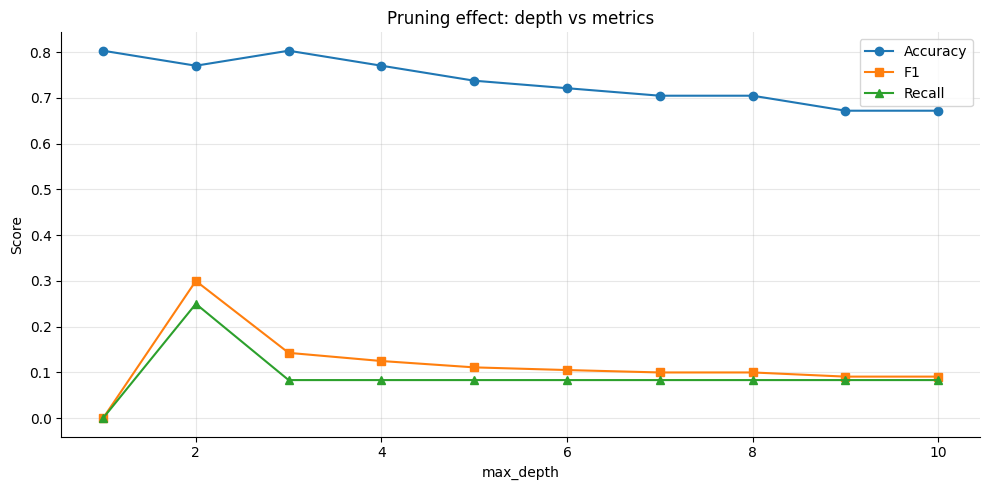

In [12]:
# Now lets do Pruned trees: sweep max_depth 1 to 10
depths = range(1, 11)
results = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    y_pred_d = tree.predict(X_test)
    results.append({
        'depth': d,
        'accuracy': accuracy_score(y_test, y_pred_d),
        'f1': f1_score(y_test, y_pred_d),
        'recall': recall_score(y_test, y_pred_d)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['depth'], results_df['accuracy'], marker='o', label='Accuracy')
ax.plot(results_df['depth'], results_df['f1'], marker='s', label='F1')
ax.plot(results_df['depth'], results_df['recall'], marker='^', label='Recall')
ax.set_xlabel('max_depth')
ax.set_ylabel('Score')
ax.set_title('Pruning effect: depth vs metrics')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV F1  : {grid_search.best_score_:.4f}')

Best params : {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV F1  : 0.1679


In [14]:
# Evaluate best model on test set
best_clf = grid_search.best_estimator_
y_pred_best = best_clf.predict(X_test)

print(f'\nBest Tree (test set)')
print(f'  Depth     : {best_clf.get_depth()}')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1        : {f1_score(y_test, y_pred_best):.4f}')


Best Tree (test set)
  Depth     : 5
  Accuracy  : 0.7541
  Precision : 0.2000
  Recall    : 0.0833
  F1        : 0.1176


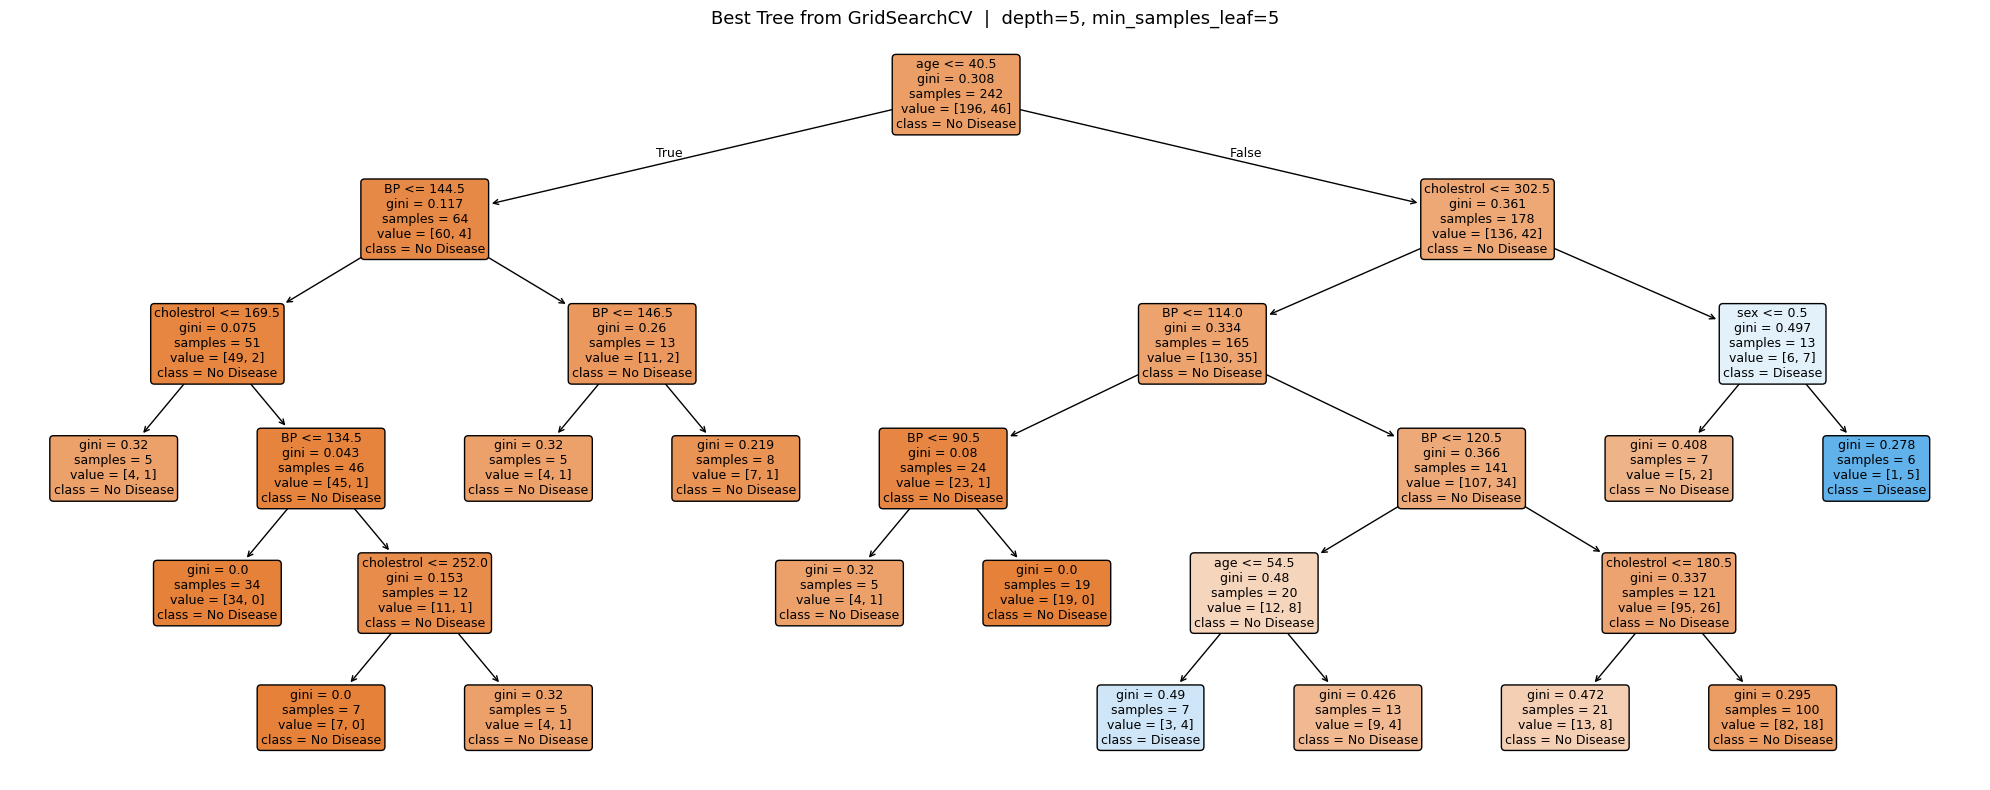

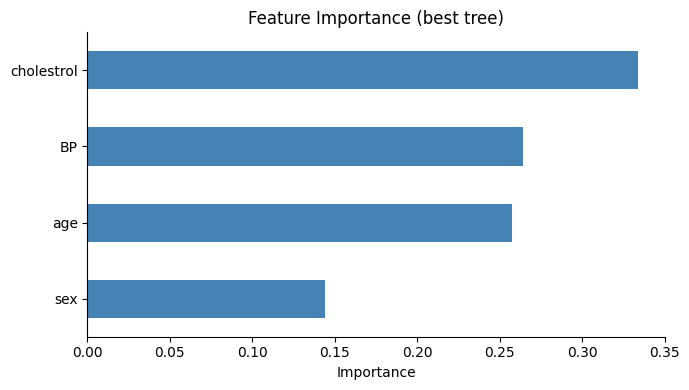

In [15]:
# Lets visualise the best tree from GridSearchCV
plt.figure(figsize=(20, 8))
plot_tree(
    best_clf,
    feature_names=['age', 'sex', 'BP', 'cholestrol'],
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(f'Best Tree from GridSearchCV  |  depth={best_clf.get_depth()}, min_samples_leaf=5', fontsize=13)
plt.tight_layout()
plt.show()

# --- Feature importance ---
importances = pd.Series(best_clf.feature_importances_, index=['age', 'sex', 'BP', 'cholestrol'])
importances.sort_values().plot(kind='barh', figsize=(7, 4), color='steelblue')
plt.title('Feature Importance (best tree)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [18]:
# 4. Now lets check for Regression Tree

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Target is ytr (continuous), same 4 features
X_reg = df[['age', 'sex', 'BP', 'cholestrol']]
y_reg = df['ytr']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Default regression tree
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

print('Default Regression Tree (unpruned)')
print(f'  Depth : {reg.get_depth()}')
print(f'  R²    : {r2_score(y_test_r, y_pred_r):.4f}')
print(f'  RMSE  : {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}')
print(f'  MAE   : {mean_absolute_error(y_test_r, y_pred_r):.4f}')

# Pruned with max_depth=3
reg_pruned = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_pruned.fit(X_train_r, y_train_r)
y_pred_rp = reg_pruned.predict(X_test_r)

print('\nPruned Regression Tree (max_depth=3)')
print(f'  Depth : {reg_pruned.get_depth()}')
print(f'  R²    : {r2_score(y_test_r, y_pred_rp):.4f}')
print(f'  RMSE  : {np.sqrt(mean_squared_error(y_test_r, y_pred_rp)):.4f}')
print(f'  MAE   : {mean_absolute_error(y_test_r, y_pred_rp):.4f}')

Default Regression Tree (unpruned)
  Depth : 15
  R²    : -1.1551
  RMSE  : 4.7429
  MAE   : 3.7164

Pruned Regression Tree (max_depth=3)
  Depth : 3
  R²    : 0.1762
  RMSE  : 2.9323
  MAE   : 2.4386


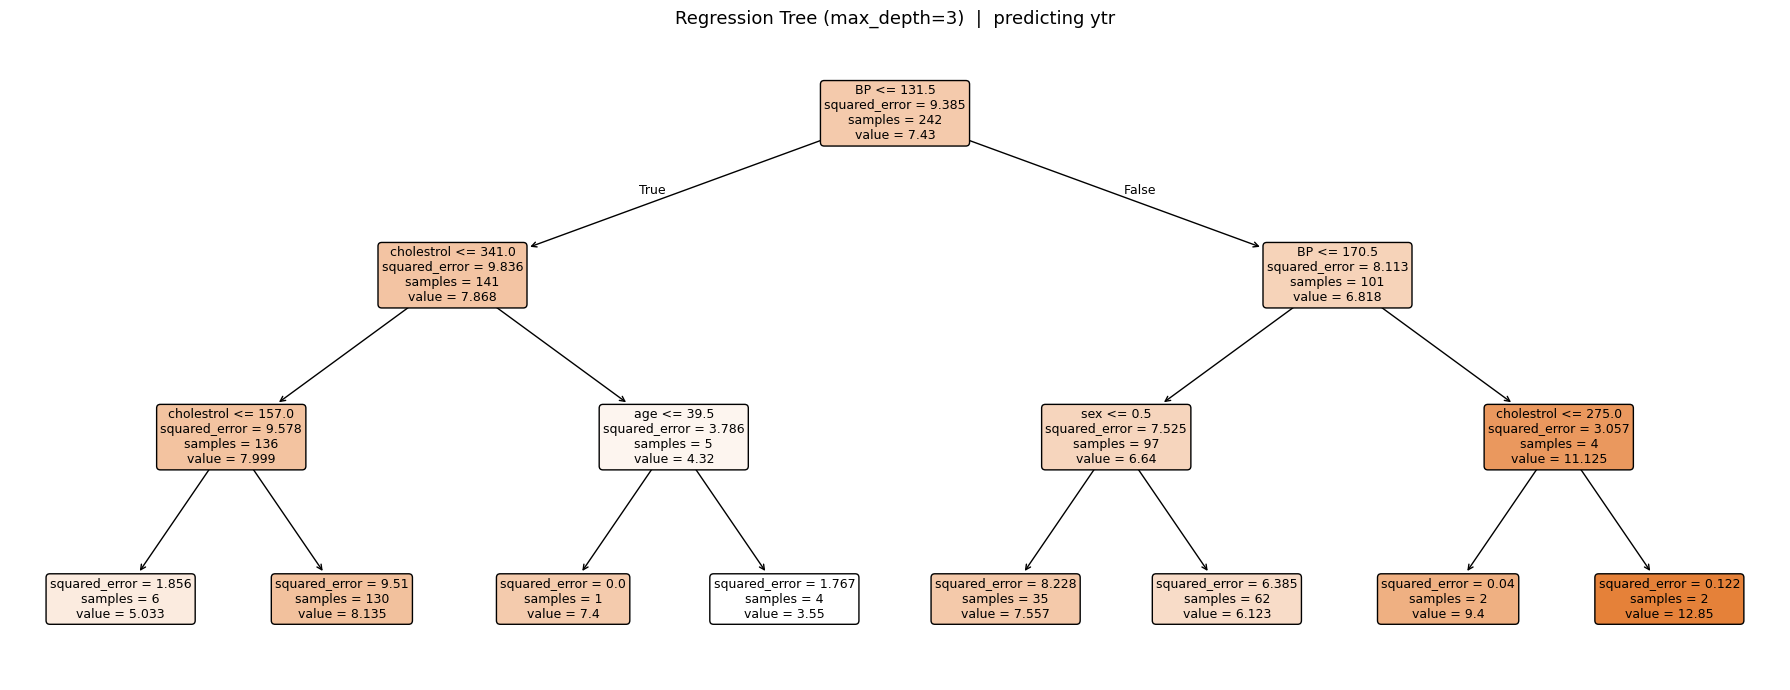

In [19]:
#  Lets visualise pruned regression tree
plt.figure(figsize=(18, 7))
plot_tree(
    reg_pruned,
    feature_names=['age', 'sex', 'BP', 'cholestrol'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Regression Tree (max_depth=3)  |  predicting ytr', fontsize=13)
plt.tight_layout()
plt.show()



In [20]:
# 5. Summary Comparison
summary = pd.DataFrame([
    {'Model': 'Classification — Unpruned (depth=15)', 'Accuracy': 0.6557, 'F1': 0.1600, 'Note': 'Overfit'},
    {'Model': 'Classification — Manual depth=2',      'Accuracy': 0.7705, 'F1': 0.3000, 'Note': 'Best test F1'},
    {'Model': 'Classification — GridSearchCV (depth=5)', 'Accuracy': 0.7541, 'F1': 0.1176, 'Note': 'Best CV F1'},
    {'Model': 'Regression — Unpruned (depth=15)',     'R²': -1.1551, 'RMSE': 4.7429, 'Note': 'Overfit'},
    {'Model': 'Regression — Pruned (depth=3)',        'R²': 0.1762,  'RMSE': 2.9323, 'Note': 'Generalises'},
])

print(summary.to_string(index=False))

                                  Model  Accuracy     F1         Note      R²   RMSE
   Classification — Unpruned (depth=15)    0.6557 0.1600      Overfit     NaN    NaN
        Classification — Manual depth=2    0.7705 0.3000 Best test F1     NaN    NaN
Classification — GridSearchCV (depth=5)    0.7541 0.1176   Best CV F1     NaN    NaN
       Regression — Unpruned (depth=15)       NaN    NaN      Overfit -1.1551 4.7429
          Regression — Pruned (depth=3)       NaN    NaN  Generalises  0.1762 2.9323


## Summary

Decision trees split data by asking yes/no questions on features. Each split tries to maximise purity (Gini impurity for classification, MSE for regression).

**Key findings on this dataset:**

- The unpruned tree (depth=15) memorised the training data and collapsed on the test set negative R² for regression, near-random F1 for classifiation
- Pruning to depth=2 manually gave the best test F1 (0.30) for the classifier
- GridSearchCV searched 64 combinations × 5 folds = 320 trees and selected depth=5 with min_samples_leaf=5 best cross-validated F1 but lower test F1 than manual depth=2, showing how small datasets (303 rows) have high variance across splits
- The regression tree (depth=3) recovered positive R² (0.18) vs the unpruned tree's R²=-1.15 so pruning is not optional on small datasets

**Three ways to control tree complexity:**

| Parameter | Effect |
|---|---|
| `max_depth` | Hard limit on how deep the tree grows |
| `min_samples_split` | Node must have at least N rows before it can split |
| `min_samples_leaf` | Every leaf must have at least N rows |

GridSearchCV finds the right combination automatically without leaking the test set.